# 任務 3：電腦視覺 (MNIST CNN 分類與資料不平衡處理)

**目標 (Objective)**：
本專案使用 PyTorch 官方提供的 MNIST 資料集，設計、實作並評估一個卷積神經網路 (CNN) 來進行數字分類。
為了充分展示在 **建模 (Modeling)**、**最佳化 (Optimization)** 以及 **處理類別不平衡 (Handling Class Imbalance)** 這三個關鍵領域的專業知識，我們將刻意人為製造資料不平衡（減少特定數字的訓練樣本），並透過權重懲罰機制來解決此問題。

## 1. 模組匯入與環境設定
首先，我們匯入必要的 Python 套件，並設定超參數 (Hyperparameters) 與運算設備 (CPU/GPU)。

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, Subset

# 設定隨機種子以確保結果可重現
torch.manual_seed(42)
np.random.seed(42)

# 超參數設定
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")


Using device: cpu


## 2. 資料載入與「人為製造」類別不平衡

標準的 MNIST 資料集是非常平衡的（每個數字大約有 6,000 張圖片）。為了展示**處理類別不平衡 (Handling Class Imbalance)** 的能力，我們在訓練集中進行抽樣，**只保留數字 `0`、`1`、`2` 各 10% 的資料**，其餘數字保留 100%。測試集則保持不變，以確保評估的公平性。

In [4]:
# 定義資料轉換 (轉為 Tensor 並進行正規化)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST 標準平均值與標準差
])

# 下載官方資料集
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 人為製造資料不平衡：數字 0, 1, 2 只保留 10%
imbalanced_indices = []
for idx, target in enumerate(train_dataset.targets):
    if target.item() in [0, 1, 2]:
        if np.random.rand() < 0.1: # 只有 10% 的機率保留
            imbalanced_indices.append(idx)
    else:
        imbalanced_indices.append(idx)

imbalanced_train_dataset = Subset(train_dataset, imbalanced_indices)

# 建立 DataLoader
train_loader = DataLoader(imbalanced_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


100.0%
100.0%
100.0%
100.0%


## 3. 分析與處理類別不平衡 (Class Imbalance)

因為我們減少了 `0, 1, 2` 的樣本數，如果直接訓練，模型會傾向預測多數類別（Majority Class）以降低整體 Loss。
**解決方案**：我們計算訓練集中每個類別的樣本數，並取其「倒數」作為 Loss 函數的權重 (Class Weights)。這樣一來，當模型分錯少數類別時，將會受到更大的懲罰。


In [5]:
# 計算不平衡資料集中的類別分佈
class_counts = np.zeros(10)
for _, target in imbalanced_train_dataset:
    class_counts[target] += 1

# 計算類別權重 (與樣本數成反比)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * 10 # 正規化權重
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)

print("Imbalanced Dataset Class Counts:", class_counts)
print("Computed Class Weights for Loss Function:\n", class_weights)


Imbalanced Dataset Class Counts: [ 585.  674.  633. 6131. 5842. 5421. 5918. 6265. 5851. 5949.]
Computed Class Weights for Loss Function:
 [2.86850533 2.48972644 2.65098834 0.27370341 0.28724334 0.30955093
 0.28355451 0.26784926 0.28680151 0.28207692]


## 4. 資料視覺化 (Data Visualization)
在進入建模之前，我們先印出幾張訓練集中的圖片，確認資料載入正確。

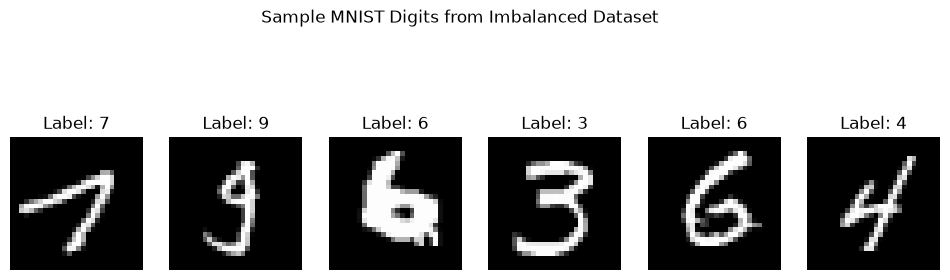

In [ ]:
def show_samples(loader):
    dataiter = iter(loader)
    images, labels = next(dataiter)
    
    fig, axes = plt.subplots(1, 6, figsize=(12, 4))
    for i in range(6):
        ax = axes[i]
        # 還原正規化以便顯示圖片
        img = images[i].numpy().squeeze() * 0.3081 + 0.1307
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Label: {labels[i].item()}")
        ax.axis('off')
    plt.suptitle("Sample MNIST Digits from Imbalanced Dataset"
    plt.show()

show_samples(train_loader)


## 5. 建模 (Modeling: CNN Architecture)
我們設計了一個兩層卷積的 CNN 模型：
1. **Conv Block 1 & 2**：透過卷積層提取空間特徵，並使用 Max Pooling 降低維度。
2. **Fully Connected Layers**：將提取的特徵攤平後進行分類。
3. **Dropout**：在全連接層中加入 `p=0.5` 的 Dropout 以防止過擬合 (Overfitting)。

In [7]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        # 第一層卷積
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # 第二層卷積
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # 全連接層
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7) # Flatten
        x = self.relu3(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = MNIST_CNN().to(DEVICE)


## 6. 最佳化策略 (Optimization)
* **Loss Function**: 使用 `CrossEntropyLoss`，並傳入先前計算好的 `class_weights_tensor` 來處理資料不平衡。
* **Optimizer**: 使用 `AdamW`，相比傳統 Adam，它具有更好的權重衰減 (Weight Decay) 機制，有助於泛化。
* **Scheduler**: 使用 `CosineAnnealingLR`，讓學習率隨著 Epoch 呈現平滑的餘弦下降，有助於模型在訓練後期穩定收斂於全局最小值。


In [8]:
# 帶入 Class Weights 的損失函數
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# 最佳化器 (AdamW)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# 學習率排程器 (Cosine Annealing)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


## 7. 模型訓練與評估 (Training & Evaluation Loop)
開始進行 Epoch 訓練，並在每一個 Epoch 結束後，使用 Test Loader 評估模型目前的 Loss 與 Accuracy。


In [9]:
train_losses = []
test_losses = []
test_accuracies = []

for epoch in range(EPOCHS):
    # 訓練階段
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    scheduler.step() # 更新學習率
    
    # 評估階段
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    avg_test_loss = test_loss / len(test_loader)
    accuracy = 100 * correct / total
    
    test_losses.append(avg_test_loss)
    test_accuracies.append(accuracy)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Test Acc: {accuracy:.2f}%")


Epoch [1/5] | Train Loss: 0.3451 | Test Loss: 0.0533 | Test Acc: 97.90%
Epoch [2/5] | Train Loss: 0.1171 | Test Loss: 0.0537 | Test Acc: 98.19%
Epoch [3/5] | Train Loss: 0.0823 | Test Loss: 0.0374 | Test Acc: 98.60%
Epoch [4/5] | Train Loss: 0.0590 | Test Loss: 0.0306 | Test Acc: 98.84%
Epoch [5/5] | Train Loss: 0.0485 | Test Loss: 0.0279 | Test Acc: 98.98%


## 8. 訓練曲線視覺化 (Prediction Curves)
最後，我們繪製 **Loss 曲線 (Train vs Test)** 以及 **準確率預測曲線 (Accuracy over Epochs)**，用以分析模型是否有順利收斂且無嚴重的過擬合現象。

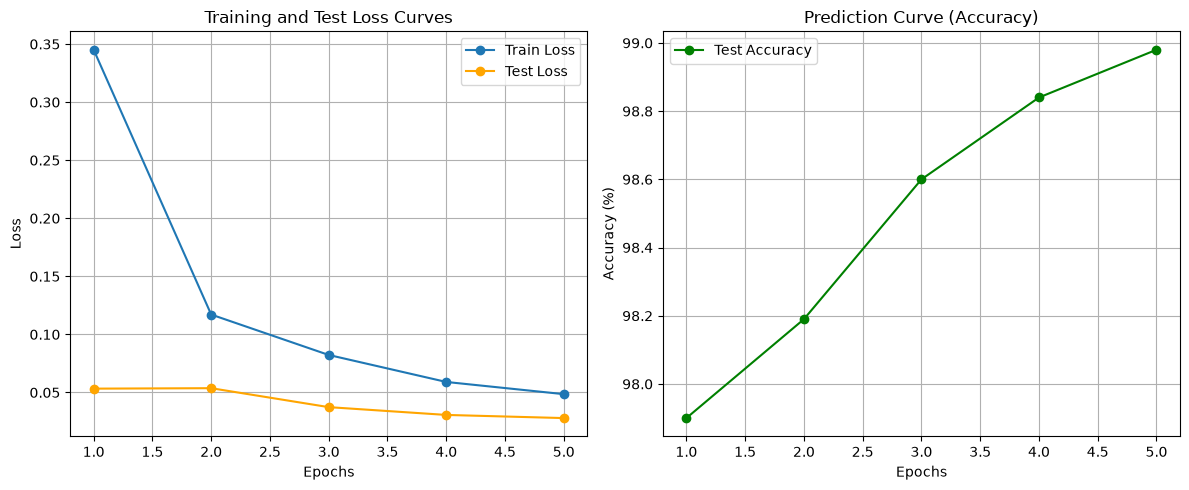

In [10]:
plt.figure(figsize=(12, 5))

# 繪製 Loss 曲線
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, EPOCHS+1), test_losses, label='Test Loss', marker='o', color='orange')
plt.title('Training and Test Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 繪製 Accuracy 曲線
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), test_accuracies, label='Test Accuracy', marker='o', color='green')
plt.title('Prediction Curve (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
